# Análise principal — Seazone Jovens Talentos 2026
## Ranking de investimento em short-stay — Itapema (SC)

Fluxo linear: preparação → Cap Rate (métrica A) → sensibilidade de ocupação → eficiência por m² (métrica C) → ranking com coluna de confiança → deep-dive → cartão do investimento.

Decisões metodológicas consolidadas em `docs/metodologia.md`. Arquivos brutos em `data/` (imutáveis).

## 0. Importações e helpers

- normalização de bairro (mapa humano em `docs/metodologia.md`)
- bin de tipologia (apartamentos): 1qto (0-1), 2q, 3q, 4q+
- corte de outliers por quantil (1-99%)

In [1]:
import pandas as pd
import numpy as np
import unicodedata

def norm(s):
    if not isinstance(s, str):
        return s
    return unicodedata.normalize('NFD', s).encode('ascii', 'ignore').decode().strip().lower()

MERGERS = {
    'jardim praiamar': 'jardim praia mar',
    'meia praia - frente mar': 'meia praia',
    'taboleiro': 'tabuleiro dos oliveiras',
    'tabuleiro': 'tabuleiro dos oliveiras',
}

def bairro_canonic(s):
    n = norm(s)
    return MERGERS.get(n, n)

def bin_tipo(nb):
    """Bin de tipologia de apartamento por nº de quartos."""
    if nb <= 1:
        return '1qto'
    if nb == 2:
        return '2q'
    if nb == 3:
        return '3q'
    return '4q+'

def clip_outliers(df, col, q_lo=0.01, q_hi=0.99):
    lo, hi = df[col].quantile([q_lo, q_hi])
    return df[(df[col] >= lo) & (df[col] <= hi)]

## 1. Preparação — lado Airbnb (receita)

Junta `Details` (tipologia) + `Mesh` (bairro) + `Price_AV` (R$/noite).
Exclui: `none`, `hotel`, `terreno`, `comercial`, `outros`, `casas`.
Tipologia binada como `1qto/2q/3q/4q+`.

In [2]:
BASE = '../data/'
D = pd.read_csv(f'{BASE}Details_Itapema.csv', encoding='utf-8',
                usecols=['airbnb_listing_id', 'number_of_bedrooms', 'listing_type', 'owner_id', 'star_rating', 'number_of_reviews', 'picture_count', 'min_nights', 'cleaning_fee', 'number_of_guests', 'is_professional', 'can_instant_book', 'is_guest_favorite'])
M = pd.read_csv(f'{BASE}Mesh_Ids_Data_Itapema.csv', encoding='utf-8',
                usecols=['airbnb_listing_id', 'suburb'])
M = M[M['suburb'].str.lower() != 'none'].dropna(subset=['suburb'])
M['bairro'] = M['suburb'].map(bairro_canonic)
P = pd.read_csv(f'{BASE}Price_AV_Itapema.csv', encoding='utf-8',
                usecols=['airbnb_listing_id', 'price'])

air = (D.merge(M[['airbnb_listing_id', 'bairro']], on='airbnb_listing_id', how='inner')
         .merge(P, on='airbnb_listing_id', how='inner'))
air = air[air['listing_type'] == 'apartamento']
air['tipo'] = air['number_of_bedrooms'].map(bin_tipo)

print('listings Airbnb (apartamento, com preço):', air['airbnb_listing_id'].nunique())
air.head()

listings Airbnb (apartamento, com preço): 911


,airbnb_listing_id,number_of_bedrooms,number_of_guests,number_of_reviews,cleaning_fee,owner_id,star_rating,picture_count,min_nights,listing_type,can_instant_book,is_professional,is_guest_favorite,bairro,price,tipo
0,991407580891691701,3,6,11,439.0,227777128,4.55,29,0,apartamento,True,True,False,meia praia,471.0,3q
1,991407580891691701,3,6,11,439.0,227777128,4.55,29,0,apartamento,True,True,False,meia praia,673.0,3q
2,991407580891691701,3,6,11,439.0,227777128,4.55,29,0,apartamento,True,True,False,meia praia,572.0,3q
3,991407580891691701,3,6,11,439.0,227777128,4.55,29,0,apartamento,True,True,False,meia praia,743.0,3q
4,991407580891691701,3,6,11,439.0,227777128,4.55,29,0,apartamento,True,True,False,meia praia,680.0,3q


## 2. Preparação — lado VivaReal (preço de compra)

Filtra `apartamento`, `sale_price` > 0, outlier 1-99%, tipologia binada.

In [3]:
V = pd.read_csv(f'{BASE}VivaReal_Itapema.csv', encoding='utf-8',
                usecols=['suburb', 'bedrooms', 'listing_type', 'sale_price', 'usable_area'])
V = V[(V['listing_type'] == 'apartamento') & (V['sale_price'] > 0)]
V = V.dropna(subset=['suburb'])
V['bairro'] = V['suburb'].map(bairro_canonic)
V['tipo'] = V['bedrooms'].map(bin_tipo)
V = clip_outliers(V, 'sale_price')

print('anúncios VivaReal (apartamento):', len(V))
V.head()

anúncios VivaReal (apartamento): 7297


,listing_type,sale_price,usable_area,bedrooms,suburb,bairro,tipo
0,apartamento,1598122.0,131,3,Meia Praia,meia praia,3q
1,apartamento,1450000.0,118,3,Meia Praia,meia praia,3q
2,apartamento,1500000.0,125,3,Castelo Branco,castelo branco,3q
3,apartamento,870000.0,70,2,Morretes,morretes,2q
4,apartamento,2150000.0,130,3,Andorinha,andorinha,3q


## 3. Tabela cruzada bairro × tipo

Agrega por célula: nº de listings Airbnb, nº de anúncios de venda,
mediana R$/noite, mediana de preço de compra.
Aplica corte de volume **N≥20 (Airbnb) e M≥15 (VivaReal)** por célula.

**Advertência**: a janela jan–abr (verão) superestima receita anualizada.
O resultado é apresentado como **Cap Rate de pico/verão**, não média anual.

In [4]:
cnt = air.groupby(['bairro', 'tipo'])['airbnb_listing_id'].nunique().rename('n_airbnb')
rec = air.groupby(['bairro', 'tipo'])['price'].median().rename('price_med_noite')

nviv = V.groupby(['bairro', 'tipo']).size().rename('n_vivareal')
prec = V.groupby(['bairro', 'tipo'])['sale_price'].median().rename('sale_price_med')
area = V.groupby(['bairro', 'tipo'])['usable_area'].median().rename('area_med_m2')

tab = (pd.DataFrame({'price_med_noite': rec, 'sale_price_med': prec,
                     'n_vivareal': nviv, 'area_med_m2': area})
         .merge(cnt, on=['bairro', 'tipo'], how='left')
         .reset_index())

tab = tab[(tab['n_airbnb'] >= 20) & (tab['n_vivareal'] >= 15)].copy()
tab['n_airbnb'] = tab['n_airbnb'].astype(int)
tab = tab.sort_values(['bairro', 'tipo'])
tab

,bairro,tipo,price_med_noite,sale_price_med,n_vivareal,area_med_m2,n_airbnb
16,centro,1qto,471.000,895000.0,18.0,53.0,78
17,centro,2q,611.000,1150000.0,89.0,86.0,65
18,centro,3q,749.000,2100000.0,438.0,131.0,45
31,meia praia,1qto,495.000,877500.0,58.0,40.0,28
32,meia praia,2q,500.000,1075000.0,244.0,85.0,187
33,meia praia,3q,711.625,1884860.0,1704.0,129.0,327
34,meia praia,4q+,1300.000,3671338.0,1375.0,188.0,65
36,morretes,2q,500.000,793950.0,1010.0,69.0,51


## 4. Cap Rate short-stay (métrica A)

`cap_rate(ocupação) = ocupação × R$/noite × 365 ÷ preço de compra`

Como a ocupação real não está nos dados, apresentamos o multiplicador `k = R$/noite × 365 ÷ preço`
e o Cap Rate para ocupações de cenário. **O ranking por `k` independe da ocupação** (ocupação
só escalona os valores, não reordena).

In [5]:
tab['k'] = tab['price_med_noite'] * 365 / tab['sale_price_med']
for o in [0.4, 0.5, 0.6, 0.7, 0.8]:
    tab[f'cap_{int(o*100)}'] = tab['k'] * o
tab['rank'] = tab['k'].rank(method='min', ascending=False).astype(int)

pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
tab.sort_values('rank')[['rank', 'bairro', 'tipo', 'n_airbnb', 'n_vivareal',
                         'price_med_noite', 'sale_price_med', 'area_med_m2',
                         'cap_50', 'cap_60', 'cap_70']]

,rank,bairro,tipo,n_airbnb,n_vivareal,price_med_noite,sale_price_med,area_med_m2,cap_50,cap_60,cap_70
36,1,morretes,2q,51,"1,010.000",500.000,"793,950.000",69.000,0.115,0.138,0.161
31,2,meia praia,1qto,28,58.000,495.000,"877,500.000",40.000,0.103,0.124,0.144
17,3,centro,2q,65,89.000,611.000,"1,150,000.000",86.000,0.097,0.116,0.136
16,4,centro,1qto,78,18.000,471.000,"895,000.000",53.000,0.096,0.115,0.134
32,5,meia praia,2q,187,244.000,500.000,"1,075,000.000",85.000,0.085,0.102,0.119
33,6,meia praia,3q,327,"1,704.000",711.625,"1,884,860.000",129.000,0.069,0.083,0.096
18,7,centro,3q,45,438.000,749.000,"2,100,000.000",131.000,0.065,0.078,0.091
34,8,meia praia,4q+,65,"1,375.000","1,300.000","3,671,338.000",188.000,0.065,0.078,0.090


## 5. Sensibilidade de ocupação

A ordem por `k` é invariante à ocupação — por isso o ranking não muda entre cenários.
Apresentamos os valores de 40% a 80% para mostrar a **faixa de retorno** por célula,
e não como se a ocupação estivesse sendo estimada aqui.

**Resultado**: o vencedor (Morretes 2qto) mantém a posição em todos os cenários;
o ranking **é estável** à ocupação.

In [6]:
c = ['k', 'cap_40', 'cap_50', 'cap_60', 'cap_70', 'cap_80']
stab = tab.sort_values('k', ascending=False)[['bairro', 'tipo', 'rank'] + c]
stab

,bairro,tipo,rank,k,cap_40,cap_50,cap_60,cap_70,cap_80
36,morretes,2q,1,0.230,0.092,0.115,0.138,0.161,0.184
31,meia praia,1qto,2,0.206,0.082,0.103,0.124,0.144,0.165
17,centro,2q,3,0.194,0.078,0.097,0.116,0.136,0.155
16,centro,1qto,4,0.192,0.077,0.096,0.115,0.134,0.154
32,meia praia,2q,5,0.170,0.068,0.085,0.102,0.119,0.136
33,meia praia,3q,6,0.138,0.055,0.069,0.083,0.096,0.110
18,centro,3q,7,0.130,0.052,0.065,0.078,0.091,0.104
34,meia praia,4q+,8,0.129,0.052,0.065,0.078,0.090,0.103


## 6. Eficiência por m² (métrica C — checagem)

`receita anual por m² = ocupação × R$/noite × 365 ÷ área mediana (VivaReal)`

Ataca a palavra **"eficiente"** da tese: um studio/1qto pode ter Cap Rate alto
**e** eficiência maior por m². R$/m²/ano, mesma estrutura de cenários.

In [7]:
tab['k_m2'] = tab['price_med_noite'] * 365 / tab['area_med_m2']
tab['efic_60'] = tab['k_m2'] * 0.6  # receita bruta anual por m² a 60% de ocupação
tab['rank_m2'] = tab['k_m2'].rank(method='min', ascending=False).astype(int)
tab.sort_values('rank_m2')[['rank_m2', 'bairro', 'tipo', 'area_med_m2',
                           'price_med_noite', 'k_m2', 'efic_60']]

,rank_m2,bairro,tipo,area_med_m2,price_med_noite,k_m2,efic_60
31,1,meia praia,1qto,40.000,495.000,"4,516.875","2,710.125"
16,2,centro,1qto,53.000,471.000,"3,243.679","1,946.208"
36,3,morretes,2q,69.000,500.000,"2,644.928","1,586.957"
17,4,centro,2q,86.000,611.000,"2,593.198","1,555.919"
34,5,meia praia,4q+,188.000,"1,300.000","2,523.936","1,514.362"
32,6,meia praia,2q,85.000,500.000,"2,147.059","1,288.235"
18,7,centro,3q,131.000,749.000,"2,086.908","1,252.145"
33,8,meia praia,3q,129.000,711.625,"2,013.513","1,208.108"


## 7. Ranking com coluna de confiança

- **Alta**: n≥50 nas duas bases e dispersão baixa (checado p/ Morretes 2qto).
- **Média**: volume razoável em uma base mas fina na outra (ex.: Centro 1qto, n_vivareal≈22).
- **Baixa**: células no limite do corte ou com dispersão alta.

A confiança diz **com quanto peso citar a célula** — não é uma propriedade do negócio.

In [8]:
def confianca(r):
    na, nv = r['n_airbnb'], r['n_vivareal']
    if na >= 100 and nv >= 100:
        return 'alta'
    if na >= 50 and nv >= 50:
        return 'media'
    if na >= 20 and nv >= 20:
        return 'baixa'
    # celulas que passaram pelo corte mas sao finas no lado de venda
    return 'baixa-fina'

tab['confianca'] = tab.apply(confianca, axis=1)

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
tab.sort_values('rank')[['rank', 'bairro', 'tipo', 'n_airbnb', 'n_vivareal',
                         'sale_price_med', 'cap_50', 'cap_60', 'cap_70', 'confianca']]

,rank,bairro,tipo,n_airbnb,n_vivareal,sale_price_med,cap_50,cap_60,cap_70,confianca
36,1,morretes,2q,51,"1,010.00","793,950.00",0.11,0.14,0.16,media
31,2,meia praia,1qto,28,58.00,"877,500.00",0.10,0.12,0.14,baixa
17,3,centro,2q,65,89.00,"1,150,000.00",0.10,0.12,0.14,media
16,4,centro,1qto,78,18.00,"895,000.00",0.10,0.12,0.13,baixa-fina
32,5,meia praia,2q,187,244.00,"1,075,000.00",0.08,0.10,0.12,alta
33,6,meia praia,3q,327,"1,704.00","1,884,860.00",0.07,0.08,0.10,alta
18,7,centro,3q,45,438.00,"2,100,000.00",0.07,0.08,0.09,baixa
34,8,meia praia,4q+,65,"1,375.00","3,671,338.00",0.06,0.08,0.09,media


## 8. Deep-dive: o que explica os extremos

Depois do ranking, examinamos características de listing (stars, superhost, reviews,
taxa de resposta, nº de fotos) dentro dos perfis vencedores vs. perdedores para
responder "o que faz um imóvel render mais de forma consistente".

In [9]:
# Deep-dive: o que separa os imóveis que rendem mais dos que menos (compactos beira-mar)
# Constrói df no nível LISTING com hosts (Details + Mesh + Price + Hosts)
import pandas as pd, numpy as np

_H = pd.read_csv(f'{BASE}Hosts_ids_Itapema.csv', encoding='utf-8')
_prec = P.groupby('airbnb_listing_id')['price'].median().rename('price_med_noite')
df = (D.merge(M[['airbnb_listing_id','bairro']], on='airbnb_listing_id', how='inner')
       .merge(_prec, on='airbnb_listing_id', how='inner')
       .merge(_H, on='owner_id', how='left'))
df = df[df['listing_type']=='apartamento']
df['tipo'] = df['number_of_bedrooms'].map(bin_tipo)
df = df.drop_duplicates('airbnb_listing_id')

FOCAL = [('centro','1qto'), ('centro','2q'), ('meia praia','1qto'), ('meia praia','2q')]
BIN = {'is_superhost':True, 'is_professional':True, 'can_instant_book':True,
       'is_guest_favorite':True, 'is_verified':True}
THRESH = {
    'star_rating': ('>= 4.8', lambda s: s>=4.8),
    'number_of_reviews': ('>= 20', lambda s: s>=20),
    'picture_count': ('>= 30', lambda s: s>=30),
    'min_nights': ('>= 3', lambda s: s>=3),
    'response_rate_shown': ('>= 90%', lambda s: s>=90),
    'years_host': ('>= 3', lambda s: s>=3),
}
H_rows = []
for bairo,t in FOCAL:
    sub = df[(df['bairro']==bairo) & (df['tipo']==t)].copy()
    feats = []
    for col,pos in BIN.items():
        if col not in sub.columns: continue
        grp = sub[sub[col]==pos]['price_med_noite'].dropna()
        grp_no = sub[sub[col]!=pos]['price_med_noite'].dropna()
        if len(grp)==0 or len(grp_no)==0: continue
        feats.append((col, len(grp), len(grp_no), grp.median(), grp_no.median()))
    for col,(labl,fn) in THRESH.items():
        val = sub[col]
        if val.isna().all(): continue
        mask = val.apply(lambda x: fn(x) if pd.notna(x) else False)
        grp = sub[mask]['price_med_noite'].dropna(); grp_no = sub[~mask]['price_med_noite'].dropna()
        if len(grp)==0 or len(grp_no)==0: continue
        feats.append((f'{col} {labl}', len(grp), len(grp_no), grp.median(), grp_no.median()))
    print(f'--- {bairo} {t} (n={len(sub)}) ---')
    for nm,n_tem,n_nao,mt,mn in feats:
        dif = mt-mn; pct = (mt/mn-1)*100 if mn else np.nan
        print(f'  {nm:<28} tem={n_tem:>4} nao={n_nao:>4} | R\ vs {mn:>6.0f} | {dif:>+6.0f} ({pct:>+5.0f}%)')
        H_rows.append({'celula':f'{bairo} {t}','carac':nm,'tem_n':n_tem,'nao_n':n_nao,
                       'tem_med':mt,'nao_med':mn,'dif':dif,'pct':pct})

h = pd.DataFrame(H_rows)
print()
print('=== características mais fortes por |% dif| médio ===')
res = h.groupby('carac')['pct'].agg(['mean','count']).sort_values('mean', key=lambda s: s.abs(), ascending=False)
print(res.head(8).round(0).to_string())
print()
print('=== TOP 3 que ELEVAM receita (pct>0) ===')
pos = h[h['pct']>0].groupby('carac')['pct'].mean().sort_values(ascending=False)
print(pos.head(3).round(0).to_string())


--- centro 1qto (n=78) ---
  is_superhost                 tem=  15 nao=  63 | R\ vs    450 |     +0 (   +0%)
  is_professional              tem=  58 nao=  20 | R\ vs    450 |    -23 (   -5%)
  can_instant_book             tem=  66 nao=  12 | R\ vs    475 |    -48 (  -10%)
  is_guest_favorite            tem=  30 nao=  48 | R\ vs    427 |    +73 (  +17%)
  star_rating >= 4.8           tem=  51 nao=  27 | R\ vs    450 |     +0 (   +0%)
  number_of_reviews >= 20      tem=  19 nao=  59 | R\ vs    450 |     +0 (   +0%)
  picture_count >= 30          tem=   9 nao=  69 | R\ vs    427 |    +73 (  +17%)
  years_host >= 3              tem=  71 nao=   7 | R\ vs    500 |    -60 (  -12%)
--- centro 2q (n=65) ---
  is_superhost                 tem=  18 nao=  47 | R\ vs    644 |   -162 (  -25%)
  is_professional              tem=  24 nao=  41 | R\ vs    449 |   +243 (  +54%)
  can_instant_book             tem=  35 nao=  30 | R\ vs    492 |   +152 (  +31%)
  is_guest_favorite            tem=  36 nao=  

## 9. Cartão do investimento

Síntese: preço de compra, receita bruta estimada, Cap Rate, payback simples.

In [10]:
# Cartão do investimento (4 células-alvo)
# Valores vem da tabela cruzada validada acima (price_med_noite, sale_price_med)
import pandas as pd
candidatas = ['centro 1qto','centro 2q','meia praia 1qto','morretes 2q']
sel = tab[(tab['bairro']+' '+tab['tipo']).isin(candidatas)].copy()
# ocupacao diferencial por perfil (premissa da recomendacao)
occ_diff = {'centro':(0.55,0.60),'meia praia':(0.60,0.65),'morretes':(0.45,0.55)}
rows=[]
for _,r in sel.iterrows():
    lo,hi = occ_diff[r['bairro']]
    for lbl,o in [('baixo',lo),('alto',hi)]:
        rec = o*r['price_med_noite']*365
        cap = rec/r['sale_price_med']
        rows.append({'bairro':r['bairro'],'tipo':r['tipo'],'ocupa':lbl,f'ocupa_pct':f'{o:.0%}',
                     'preco_compra':r['sale_price_med'],'preco_noite':r['price_med_noite'],
                     'receita_anual':rec,'cap_rate':cap,'payback':1/cap})
cartao = pd.DataFrame(rows)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print(cartao[['bairro','tipo','ocupa_pct','preco_compra','preco_noite','receita_anual','cap_rate','payback']].to_string(index=False))
print()
print('Nota: cap_rate = receita bruta / preço; receita sem custos operacionais; janela jan-abr superestima.')


    bairro tipo ocupa_pct  preco_compra  preco_noite  receita_anual  cap_rate  payback
    centro 1qto       55%    895,000.00       471.00      94,553.25      0.11     9.47
    centro 1qto       60%    895,000.00       471.00     103,149.00      0.12     8.68
    centro   2q       55%  1,150,000.00       611.00     122,658.25      0.11     9.38
    centro   2q       60%  1,150,000.00       611.00     133,809.00      0.12     8.59
meia praia 1qto       60%    877,500.00       495.00     108,405.00      0.12     8.09
meia praia 1qto       65%    877,500.00       495.00     117,438.75      0.13     7.47
  morretes   2q       45%    793,950.00       500.00      82,125.00      0.10     9.67
  morretes   2q       55%    793,950.00       500.00     100,375.00      0.13     7.91

Nota: cap_rate = receita bruta / preço; receita sem custos operacionais; janela jan-abr superestima.


## 10. Mapa interativo — Cap Rate por célula (premissa diferencial)

Um marcador por combinação bairro x tipo, no centroide dos imóveis Airbnb.
A cor é o **Cap Rate** no cenário **diferencial (faixa alta de ocupação por perfil)**;
o tamanho é proporcional ao nº de imóveis. Cinza = célula fora do ranking (volume cortado).

> O OpenStreetMap requer internet para carregar o mapa. Clique nos marcadores para
> ver bairro, tipologia, Cap Rate e nº de imóveis.


In [11]:
# Executa o script do mapa (scripts/map_cell.py) no contexto das variáveis atuais
# O script constrói e deixa 'm' (folium.Map) no globals; exibimos explicitamente.
with open('../scripts/map_cell.py', encoding='utf-8') as _f:
    exec(compile(_f.read(), 'map_cell', 'exec'))

# Display explícito do mapa (última expressão da célula)
from IPython.display import display
display(m)


Mapa salvo em .\mapa_interativo.html (28.7 KB)
Mapa com centroides por célula (24 células) — role o notebook e veja inline.
Usou contexto do notebook.


## 10b. Mapa estático (funciona offline e no GitHub/nbviewer)

Complemento ao mapa interativo: mesmo scatter por latitude/longitude, agora como
imagem estática (matplotlib) — garantia de que a rápida leitura do ranking aparece
mesmo sem Jupyter aberto.


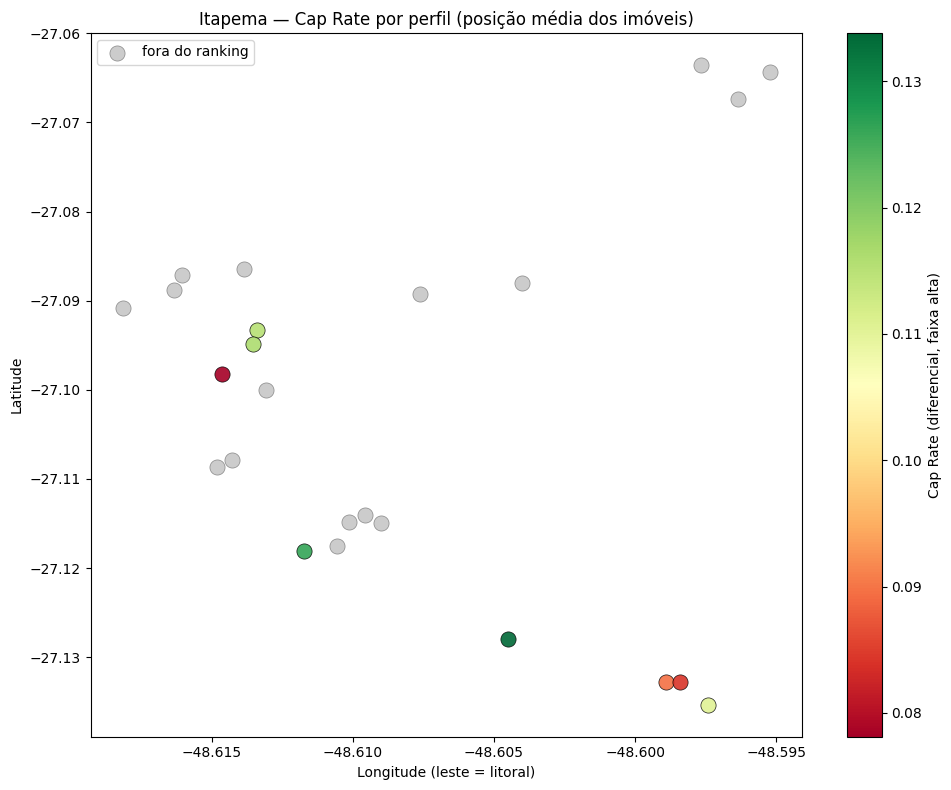

In [12]:
# Mapa estático de Cap Rate (scatter otimizado: 1 ponto por célula)
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

a = _air_map[['latitude', 'longitude', 'bairro', 'tipo']].copy()
a = a.merge(_tab_map[['bairro', 'tipo', 'cap_cell']], on=['bairro', 'tipo'], how='left')
cel = a.groupby(['bairro', 'tipo'], as_index=False).agg(lat=('latitude', 'mean'), lon=('longitude', 'mean'))
cel = cel.merge(_tab_map[['bairro', 'tipo', 'cap_cell']], on=['bairro', 'tipo'], how='left')

fig, ax = plt.subplots(figsize=(10, 8))
cmap = plt.cm.RdYlGn
ok = cel.dropna(subset=['cap_cell'])
norm = mcolors.Normalize(vmin=ok['cap_cell'].min(), vmax=ok['cap_cell'].max())
for _, r in ok.iterrows():
    ax.scatter(r['lon'], r['lat'], c=[cmap(norm(r['cap_cell']))], s=120, alpha=0.9, edgecolors='k', linewidths=0.5, zorder=3)
ax.scatter(cel[cel['cap_cell'].isna()]['lon'], cel[cel['cap_cell'].isna()]['lat'],
           c='gray', s=120, alpha=0.4, edgecolors='k', linewidths=0.5, label='fora do ranking')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cb = fig.colorbar(sm, ax=ax); cb.set_label('Cap Rate (diferencial, faixa alta)')
ax.set_title('Itapema — Cap Rate por perfil (posição média dos imóveis)')
ax.set_xlabel('Longitude (leste = litoral)'); ax.set_ylabel('Latitude')
ax.legend()
plt.tight_layout()
plt.show()
